# Wave orbital effects on drogued drifter drift

If we drive the drogued drifter model with a Stokes drift profile (steady vertical shear), do we get the same result as driving it with explicit wave orbital velocities?

The Stokes drift profile is a time-mean description of wave-driven transport. It correctly predicts the drift of a passive fluid parcel, but the drogued drifter is not a passive parcel -- it is a mechanical system with inertia. The pole pendulum has a natural period of about 27 s, much longer than the 2--4 s wave periods typical of Baltic wind seas. The drifter therefore cannot follow the wave-frequency forcing and acts as a low-pass filter. The Stokes profile approach, which assumes the drifter instantaneously adjusts to the local shear, overestimates the wave-driven drift.

## Imports

In [1]:
import copernicusmarine as cm
import matplotlib.pyplot as plt
import numpy as np

from drogued_drifters import DroguedDrifter

/Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters

Wave conditions from the southern Kiel Bight P95 case (notebook 04).
The wave amplitude is derived from the target surface Stokes drift
using the monochromatic deep-water relation $u_{St}(0) = A^2 \sigma k$.

Note: the deep-water dispersion $k = \sigma^2/g$ overestimates $k$ in the
shallow Kiel Bight (10-20 m depth). This makes the orbital velocity
decay too fast with depth. The qualitative result (filtering of wave
forcing by the pendulum) is not affected.

In [2]:
G = 9.81                          # gravitational acceleration [m/s^2]
TP = 4.2                          # peak period [s]
U_ST_TARGET = 0.19                # target surface Stokes drift [m/s]
U_MEAN = 0.23                     # background Eulerian current [m/s]

T_TOTAL = 100.0                   # integration time [s]

N_SEEDS = 10                      # number of random phase realizations
RANDOM_SEED = 7                   # RNG seed for phase generation

In [3]:
g = G
Tp = TP
u_St_target = U_ST_TARGET
U_mean = U_MEAN
T_total = T_TOTAL

sigma = 2 * np.pi / Tp
k = sigma**2 / g                  # deep water dispersion
A = np.sqrt(u_St_target / (sigma * k))
Hs = 2 * A

u_St_0 = A**2 * sigma * k        # surface Stokes drift [m/s]

dt_out = Tp / 60                  # output interval [s]
t_eval = np.arange(0, T_total, dt_out)

dd = DroguedDrifter()

print(f"Hs = {Hs:.2f} m, Tp = {Tp} s, k = {k:.3f} /m")
print(f"Surface Stokes drift = {u_St_0:.4f} m/s")
print(f"Background current = {U_mean} m/s")

Hs = 1.49 m, Tp = 4.2 s, k = 0.228 /m
Surface Stokes drift = 0.1900 m/s
Background current = 0.23 m/s


## Monochromatic wave

We define two velocity callbacks for the drogued drifter model:

1. **Wave orbital**: the buoy and drogue experience instantaneous linear wave orbital velocities plus the background current. The orbital velocity at depth $z$ is $A \sigma \exp(-kz) \cos(kx - \sigma t)$.
2. **Stokes profile**: the buoy and drogue experience steady Stokes drift $A^2 \sigma k \exp(-2kz)$ plus the background current. No time-varying orbital motion.

Both are driven by the same wave parameters. If the drifter responded instantaneously to vertical shear, the two would give the same mean drift.

In [ ]:
def wave_uv(*, t, x, y, z):
    """Instantaneous wave orbital velocity + background current.

    z is positive upward (negative below MSL).
    At depth z <= 0: exp(k*z) = exp(-k*|z|) decays with depth.
    """
    phase = k * x - sigma * t
    U = U_mean + A * sigma * np.exp(k * z) * np.cos(phase)
    return U, 0.0


def stokes_uv(*, t, x, y, z):
    """Stokes drift profile + background current (steady).

    z is positive upward (negative below MSL).
    At depth z <= 0: exp(2*k*z) = exp(-2*k*|z|) decays with depth.
    """
    U = U_mean + u_St_0 * np.exp(2 * k * z)
    return U, 0.0

In [5]:
ds_wave = DroguedDrifter(get_uv=wave_uv).get_full_solution(
    t_span=(0, T_total), t_eval=t_eval, atol=1e-6, rtol=1e-6,
)
ds_stokes = DroguedDrifter(get_uv=stokes_uv).get_full_solution(
    t_span=(0, T_total), t_eval=t_eval, atol=1e-6, rtol=1e-6,
)

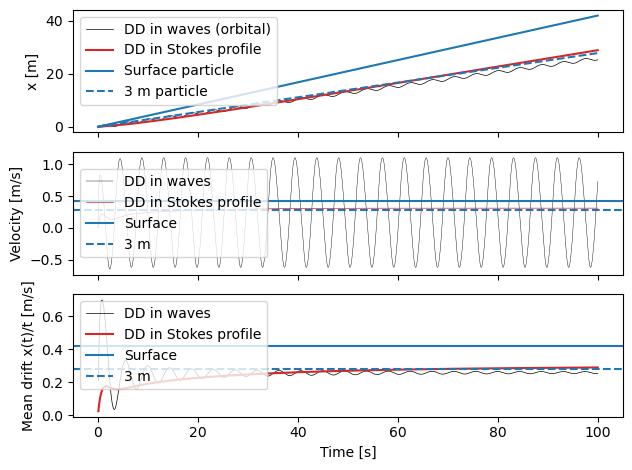

In [6]:
t = ds_wave.time.values
x_wave = ds_wave.x.values
x_stokes = ds_stokes.x.values
x_surface = (U_mean + u_St_0) * t
u_St_3 = u_St_0 * np.exp(-2 * k * dd.l)
x_3m = (U_mean + u_St_3) * t

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)

ax1.plot(t, x_wave, "k", linewidth=0.5, label="DD in waves (orbital)")
ax1.plot(t, x_stokes, color="tab:red", label="DD in Stokes profile")
ax1.plot(t, x_surface, color="tab:blue", label="Surface particle")
ax1.plot(t, x_3m, color="tab:blue", linestyle="--", label="3 m particle")
ax1.set_ylabel("x [m]")
ax1.legend()

ax2.plot(t, ds_wave.xd.values, "k", linewidth=0.3, label="DD in waves")
ax2.plot(t, ds_stokes.xd.values, color="tab:red", linewidth=0.5, label="DD in Stokes profile")
ax2.axhline(U_mean + u_St_0, color="tab:blue", linestyle="-", label="Surface")
ax2.axhline(U_mean + u_St_3, color="tab:blue", linestyle="--", label="3 m")
ax2.set_ylabel("Velocity [m/s]")
ax2.legend()

t_nz = t[1:]
ax3.plot(t_nz, x_wave[1:] / t_nz, "k", linewidth=0.5, label="DD in waves")
ax3.plot(t_nz, x_stokes[1:] / t_nz, color="tab:red", label="DD in Stokes profile")
ax3.axhline(U_mean + u_St_0, color="tab:blue", linestyle="-", label="Surface")
ax3.axhline(U_mean + u_St_3, color="tab:blue", linestyle="--", label="3 m")
ax3.set_ylabel("Mean drift x(t)/t [m/s]")
ax3.set_xlabel("Time [s]")
ax3.legend()

plt.tight_layout()
plt.show()

## 3-component wave from CMEMS partitions

The CMEMS Baltic wave model provides partitioned wave parameters: wind
waves (WW), primary swell (SW1), and secondary swell (SW2), each with
their own significant wave height, period, and direction. We extract a
single strong-Stokes timestep (2023-04-25 12:00) from the southern Kiel
Bight and build a 3-component wave field.

In [7]:
ds_wav = cm.open_dataset(
    dataset_id="cmems_mod_bal_wav_anfc_PT1H-i",
    service="arco-geo-series",
).sel(
    longitude=slice(9.75, 11.0),
    latitude=slice(54.3, 54.55),
    time=slice("2023-04-25T12:00", "2023-04-25T12:00"),
)[
    ["VHM0_WW", "VTM01_WW", "VMDR_WW",
     "VHM0_SW1", "VTM01_SW1", "VMDR_SW1",
     "VHM0_SW2", "VTM01_SW2", "VMDR_SW2"]
].load()

def _med(v):
    return float(ds_wav[v].median())

components = []
for prefix, name in [("WW", "Wind wave"), ("SW1", "Swell 1"), ("SW2", "Swell 2")]:
    hs_i = _med(f"VHM0_{prefix}")
    T_i = _med(f"VTM01_{prefix}")
    dir_i = _med(f"VMDR_{prefix}")
    if hs_i > 0.01 and np.isfinite(T_i):
        A_i = hs_i / 2
        sigma_i = 2 * np.pi / T_i
        k_i = sigma_i**2 / g
        theta_i = np.radians(270 - dir_i)
        components.append({
            "name": name, "A": A_i, "sigma": sigma_i, "k": k_i,
            "dir_x": np.cos(theta_i), "dir_y": np.sin(theta_i),
            "Hs": hs_i, "T": T_i, "dir_from": dir_i,
        })

for c in components:
    u_St_i = c["A"]**2 * c["sigma"] * c["k"]
    print(f'{c["name"]:12s}: Hs={c["Hs"]:.3f} m, T={c["T"]:.1f} s, '
          f'dir={c["dir_from"]:.0f} deg, u_St(0)={u_St_i:.4f} m/s')

INFO - 2026-04-01T10:23:49Z - Selected dataset version: "202311"


INFO - 2026-04-01T10:23:49Z - Selected dataset part: "default"


Wind wave   : Hs=1.216 m, T=3.5 s, dir=295 deg, u_St(0)=0.2220 m/s
Swell 1     : Hs=0.018 m, T=2.0 s, dir=63 deg, u_St(0)=0.0003 m/s


In [ ]:
rng = np.random.default_rng(RANDOM_SEED)
for c in components:
    c["phase"] = rng.uniform(0, 2 * np.pi)


def wave_3c_uv(*, t, x, y, z):
    """3-component wave orbital velocity + background current.

    z is positive upward (negative below MSL).
    At depth z <= 0: exp(k*z) = exp(-k*|z|) decays with depth.
    """
    U = U_mean
    V = 0.0
    for c in components:
        phase = c["k"] * x - c["sigma"] * t + c["phase"]
        amp = c["A"] * c["sigma"] * np.exp(c["k"] * z) * np.cos(phase)
        U += amp * c["dir_x"]
        V += amp * c["dir_y"]
    return U, V


def stokes_3c_uv(*, t, x, y, z):
    """3-component Stokes drift profile + background current (steady).

    z is positive upward (negative below MSL).
    At depth z <= 0: exp(2*k*z) = exp(-2*k*|z|) decays with depth.
    """
    U = U_mean + sum(
        c["A"]**2 * c["sigma"] * c["k"] * np.exp(2 * c["k"] * z) * c["dir_x"]
        for c in components
    )
    V = sum(
        c["A"]**2 * c["sigma"] * c["k"] * np.exp(2 * c["k"] * z) * c["dir_y"]
        for c in components
    )
    return U, V

In [9]:
ds_3c_wave = DroguedDrifter(get_uv=wave_3c_uv).get_full_solution(
    t_span=(0, T_total), t_eval=t_eval, atol=1e-6, rtol=1e-6,
)
ds_3c_stokes = DroguedDrifter(get_uv=stokes_3c_uv).get_full_solution(
    t_span=(0, T_total), t_eval=t_eval, atol=1e-6, rtol=1e-6,
)

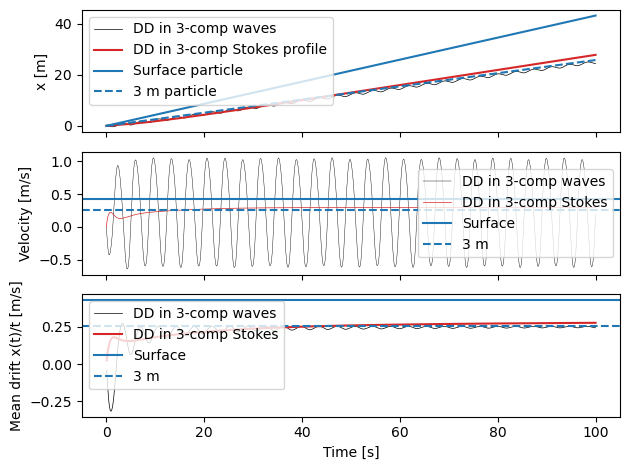

In [10]:
u_St_0_3c = sum(c["A"]**2 * c["sigma"] * c["k"] * c["dir_x"] for c in components)
u_St_3m_3c = sum(
    c["A"]**2 * c["sigma"] * c["k"] * np.exp(-2 * c["k"] * dd.l) * c["dir_x"]
    for c in components
)
u_surf_3c = U_mean + u_St_0_3c
u_3m_3c = U_mean + u_St_3m_3c

x_3c_wave = ds_3c_wave.x.values
x_3c_stokes = ds_3c_stokes.x.values

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)

ax1.plot(t_eval, x_3c_wave, "k", linewidth=0.5, label="DD in 3-comp waves")
ax1.plot(t_eval, x_3c_stokes, color="tab:red", label="DD in 3-comp Stokes profile")
ax1.plot(t_eval, u_surf_3c * t_eval, color="tab:blue", label="Surface particle")
ax1.plot(t_eval, u_3m_3c * t_eval, color="tab:blue", linestyle="--", label="3 m particle")
ax1.set_ylabel("x [m]")
ax1.legend()

ax2.plot(t_eval, ds_3c_wave.xd.values, "k", linewidth=0.3, label="DD in 3-comp waves")
ax2.plot(t_eval, ds_3c_stokes.xd.values, color="tab:red", linewidth=0.5, label="DD in 3-comp Stokes")
ax2.axhline(u_surf_3c, color="tab:blue", linestyle="-", label="Surface")
ax2.axhline(u_3m_3c, color="tab:blue", linestyle="--", label="3 m")
ax2.set_ylabel("Velocity [m/s]")
ax2.legend()

t_nz = t_eval[1:]
ax3.plot(t_nz, x_3c_wave[1:] / t_nz, "k", linewidth=0.5, label="DD in 3-comp waves")
ax3.plot(t_nz, x_3c_stokes[1:] / t_nz, color="tab:red", label="DD in 3-comp Stokes")
ax3.axhline(u_surf_3c, color="tab:blue", linestyle="-", label="Surface")
ax3.axhline(u_3m_3c, color="tab:blue", linestyle="--", label="3 m")
ax3.set_ylabel("Mean drift x(t)/t [m/s]")
ax3.set_xlabel("Time [s]")
ax3.legend()

plt.tight_layout()
plt.show()

## Pendulum eigenfrequency analysis

The pole pendulum has a natural period determined by the effective
gravity restoring force and the combined inertia (dry mass + added mass):

$$T_p = 2\pi \sqrt{\frac{(m_d + \tilde{m}_d) \, l}{(m_d - \hat{m}_d) \, g}}$$

The added mass ($\tilde{m}_d = 101$ kg) dominates the inertia, making
$T_p \approx 27$ s. The system is heavily overdamped by the quadratic
drogue drag ($k_d = 154$ kg/m), so its response to forcing is
well-approximated by a first-order low-pass filter:

$$H(\omega) = \frac{1}{1 + (\omega / \omega_p)^2}$$

rather than the full second-order oscillator transfer function. For
Baltic wind seas ($T = 2\text{-}4$ s, $\omega / \omega_p \gg 1$),
the response is near zero.

Pendulum natural period: 27.1 s
Pendulum natural frequency: 0.232 rad/s

   Component   T [s]   omega/omega_p       H
        Mono     4.2             6.5   0.023
   Wind wave     3.5             7.8   0.016
     Swell 1     2.0            13.7   0.005


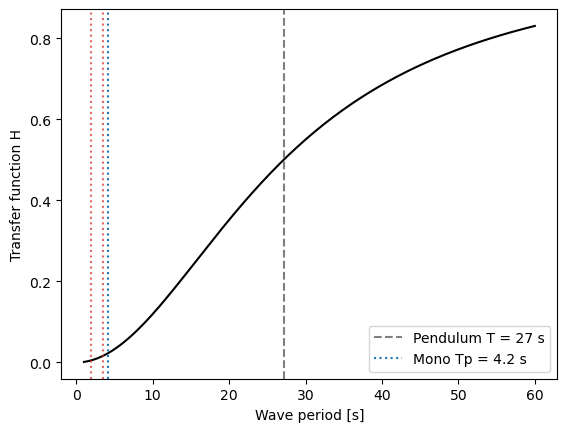

In [11]:
omega_p = np.sqrt((dd.m_d - dd.m_hat_d) * dd.g / ((dd.m_d + dd.m_tilde_d) * dd.l))
T_pendulum = 2 * np.pi / omega_p

print(f"Pendulum natural period: {T_pendulum:.1f} s")
print(f"Pendulum natural frequency: {omega_p:.3f} rad/s")
print()

# Transfer function for each wave component
print(f"{'Component':>12s}  {'T [s]':>6s}  {'omega/omega_p':>14s}  {'H':>6s}")
for T_w, label in [(Tp, "Mono")] + [(c["T"], c["name"]) for c in components]:
    omega_w = 2 * np.pi / T_w
    ratio = omega_w / omega_p
    H = 1 / (1 + ratio**2)
    print(f"{label:>12s}  {T_w:6.1f}  {ratio:14.1f}  {H:6.3f}")

# Plot transfer function
T_range = np.linspace(1, 60, 200)
omega_range = 2 * np.pi / T_range
H_range = 1 / (1 + (omega_range / omega_p)**2)

fig, ax = plt.subplots()
ax.plot(T_range, H_range, "k")
ax.axvline(T_pendulum, color="tab:gray", linestyle="--", label=f"Pendulum T = {T_pendulum:.0f} s")
for c in components:
    ax.axvline(c["T"], color="tab:red", linestyle=":", alpha=0.7)
ax.axvline(Tp, color="tab:blue", linestyle=":", label=f"Mono Tp = {Tp} s")
ax.set_xlabel("Wave period [s]")
ax.set_ylabel("Transfer function H")
ax.legend()
plt.show()

## Multi-seed verification

The drift difference between waves and Stokes profile depends on the
initial wave phase. We run 10 random phase realizations of the
3-component wave and report the mean and standard deviation of the
drift difference.

In [ ]:
t_last = t_eval > T_total / 2

def _mean_drift(x_arr):
    return (x_arr[t_last][-1] - x_arr[t_last][0]) / (t_eval[t_last][-1] - t_eval[t_last][0])

u_stokes_3c_ref = _mean_drift(x_3c_stokes)

drifts = []
for seed in range(N_SEEDS):
    rng_trial = np.random.default_rng(seed)
    comps_trial = [dict(c, phase=rng_trial.uniform(0, 2 * np.pi)) for c in components]

    def _uv(*, t, x, y, z, _comps=comps_trial):
        """Wave orbital velocity callback (z-up: z <= 0 below MSL)."""
        U = U_mean
        V = 0.0
        for c in _comps:
            ph = c["k"] * x - c["sigma"] * t + c["phase"]
            amp = c["A"] * c["sigma"] * np.exp(c["k"] * z) * np.cos(ph)
            U += amp * c["dir_x"]
            V += amp * c["dir_y"]
        return U, V

    ds_t = DroguedDrifter(get_uv=_uv).get_full_solution(
        t_span=(0, T_total), t_eval=t_eval, atol=1e-6, rtol=1e-6,
    )
    drifts.append(_mean_drift(ds_t.x.values))

drifts = np.array(drifts)
diff = drifts - u_stokes_3c_ref

print(f"3-component DD in waves ({N_SEEDS} seeds):")
print(f"  Mean drift:  {drifts.mean():.5f} +/- {drifts.std():.5f} m/s")
print(f"  Stokes DD:   {u_stokes_3c_ref:.5f} m/s")
print(f"  Difference:  {diff.mean()*1000:.1f} +/- {diff.std()*1000:.1f} mm/s")